# Projective Contraction of Sinkhorn Scalings

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository LICENSE file.

This notebook generates the figure labeled `fig:sinkhorn-projective-scaling-simplex`. It visualizes one complete Sinkhorn cycle on the left scaling. For positive marginals $a,b$ and a positive kernel $K$, define

$$
R(v)=\frac{a}{Kv},\qquad
C(u)=\frac{b}{K^\top u},\qquad
F_u(u)=R(C(u))
=\frac{a}{K\!\left(b/(K^\top u)\right)},
$$

where divisions are entrywise. The map $F_u$ is positively homogeneous, so it induces a nonlinear map on the probability simplex after normalization.

In [ ]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


In [2]:
from pathlib import Path
import logging
import os
ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")


import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    GRAY,
    interp_color,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
logging.getLogger("fontTools").setLevel(logging.ERROR)

NAME = "sinkhorn-projective-scaling-simplex"
OUT = figure_dir(NAME)
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"

## The same kernels inside a Sinkhorn cycle

We use

$$
\Sigma_3=\left\{p\in\mathbb R_+^3:\mathbf1_3^\top p=1\right\}
$$

as a gauge section of the positive cone. For a nonzero $u\geq0$, write

$$
\widehat u=\frac{u}{\langle u,\mathbf1_3\rangle},
\qquad
\widehat F_u(p)=\frac{F_u(p)}{\langle F_u(p),\mathbf1_3\rangle}.
$$

Since $F_u(su)=sF_u(u)$ for $s>0$, this normalization retains all projective
information. A complete Sinkhorn cycle becomes

$$
\widehat u^{(\ell+1)}=\widehat F_u\!\left(\widehat u^{(\ell)}\right).
$$

We reuse the explicit family

$$
K_{\rho,\delta}=\rho I_3
 +(1-\rho)\frac{\mathbf1_3\mathbf1_3^\top}{3}
 +\delta
 \begin{pmatrix}0&-1&1\\1&0&-1\\-1&1&0\end{pmatrix},
$$

with $\rho=.90$: the panels use $\delta=0,+.014,-.014$. All three use the
same uniform Sinkhorn marginals

$$
a=b=\frac13\mathbf1_3.
$$

The two nonzero cyclic parameters turn the nested images in opposite
directions. Because these kernels are doubly stochastic, both the fixed
scaling ray $\widehat u_i^\star$ and the stationary Markov vector $\pi_i$ are
$\mathbf1_3/3$ in this experiment; this coincidence does not hold for general
kernels and marginals.


In [3]:
SIMPLEX_VERTICES = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, np.sqrt(3.0) / 2.0],
    ]
)

MARGINAL = np.ones(3) / 3.0
ITERATIONS = list(range(16))
RHO = 0.90
DELTA = 0.014
UNIFORM_PROJECTOR = np.ones((3, 3)) / 3.0
TURN_GENERATOR = np.array(
    [
        [0.0, -1.0, 1.0],
        [1.0, 0.0, -1.0],
        [-1.0, 1.0, 0.0],
    ]
)


def markov_kernel(delta: float) -> np.ndarray:
    """Construct a positive doubly stochastic Sinkhorn kernel.

    Args:
        delta: Signed amplitude of the cyclic skew component.

    Returns:
        Matrix ``K_(rho, delta)`` for the fixed parameter ``rho = RHO``.
    """
    return (
        RHO * np.eye(3)
        + (1.0 - RHO) * UNIFORM_PROJECTOR
        + delta * TURN_GENERATOR
    )


KERNEL_SPECS = [
    {"kernel": markov_kernel(0.0), "delta": 0.0, "turn_sign": 0},
    {"kernel": markov_kernel(+DELTA), "delta": +DELTA, "turn_sign": -1},
    {"kernel": markov_kernel(-DELTA), "delta": -DELTA, "turn_sign": 1},
]


def sample_simplex_boundary(points_per_edge: int = 700) -> np.ndarray:
    """Sample the oriented boundary of the three-state probability simplex.

    Args:
        points_per_edge: Number of samples on each edge, excluding its endpoint.

    Returns:
        Array of shape ``(3 * points_per_edge, 3)`` in cyclic boundary order.
    """
    parameter = np.linspace(0.0, 1.0, points_per_edge, endpoint=False)
    zeros = np.zeros_like(parameter)
    first_edge = np.column_stack((1.0 - parameter, parameter, zeros))
    second_edge = np.column_stack((zeros, 1.0 - parameter, parameter))
    third_edge = np.column_stack((parameter, zeros, 1.0 - parameter))
    return np.vstack((first_edge, second_edge, third_edge))


def normalize_rows(vectors: np.ndarray) -> np.ndarray:
    """Normalize nonzero nonnegative row vectors to the probability simplex.

    Args:
        vectors: Array whose rows have strictly positive total mass.

    Returns:
        Row-normalized copy of ``vectors``.
    """
    vectors = np.asarray(vectors, dtype=float)
    row_sums = vectors.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0.0):
        raise ValueError("each vector must have positive total mass")
    return vectors / row_sums


def sinkhorn_u_cycle(points: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Apply one normalized full Sinkhorn cycle to left scalings.

    Each input row represents a left scaling ``u``. The function computes
    ``v = b / (K.T @ u)``, then ``u_next = a / (K @ v)``, and finally fixes
    the projective gauge by imposing ``sum(u_next) = 1``.

    Args:
        points: Nonzero nonnegative left scalings stored row-wise.
        kernel: Strictly positive square Sinkhorn kernel.

    Returns:
        Normalized next-cycle left scalings, one per input row.
    """
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != kernel.shape[0]:
        raise ValueError("points and kernel have incompatible dimensions")
    if np.any(points < 0.0) or np.any(kernel <= 0.0):
        raise ValueError("the scalings must be nonnegative and K positive")

    # Row storage turns K.T @ u into u.T @ K.
    right_scalings = MARGINAL[None, :] / (points @ kernel)
    left_scalings = MARGINAL[None, :] / (right_scalings @ kernel.T)
    return normalize_rows(left_scalings)


def sinkhorn_fixed_ray(
    kernel: np.ndarray,
    tolerance: float = 1e-14,
    max_iterations: int = 20_000,
) -> np.ndarray:
    """Compute the normalized fixed ray of the full Sinkhorn cycle.

    Args:
        kernel: Strictly positive square Sinkhorn kernel.
        tolerance: Infinity-norm stopping tolerance between normalized iterates.
        max_iterations: Maximum number of complete Sinkhorn cycles.

    Returns:
        Probability vector representing the unique left-scaling fixed ray.

    Raises:
        RuntimeError: If the fixed-point iteration misses the tolerance.
    """
    current = MARGINAL[None, :].copy()
    for _ in range(max_iterations):
        updated = sinkhorn_u_cycle(current, kernel)
        if np.max(np.abs(updated - current)) <= tolerance:
            return updated[0]
        current = updated
    raise RuntimeError("Sinkhorn fixed-ray iteration did not converge")


def stationary_vector(kernel: np.ndarray) -> np.ndarray:
    """Recover the stationary probability of a column-stochastic kernel.

    Args:
        kernel: Positive column-stochastic matrix.

    Returns:
        Normalized positive right eigenvector associated with eigenvalue one.
    """
    eigenvalues, eigenvectors = np.linalg.eig(kernel)
    index = int(np.argmin(np.abs(eigenvalues - 1.0)))
    stationary = np.real(eigenvectors[:, index])
    if stationary.sum() < 0.0:
        stationary = -stationary
    return stationary / stationary.sum()


def birkhoff_factor(kernel: np.ndarray) -> float:
    """Return the Birkhoff--Hopf contraction factor of a positive matrix.

    Args:
        kernel: Strictly positive matrix.

    Returns:
        Value ``lambda(K)`` controlling contraction in Hilbert's metric.
    """
    if np.any(kernel <= 0.0):
        raise ValueError("Birkhoff contraction requires a positive matrix")
    n_rows, n_columns = kernel.shape
    eta = max(
        kernel[i, k] * kernel[j, ell]
        / (kernel[j, k] * kernel[i, ell])
        for i in range(n_rows)
        for j in range(n_rows)
        for k in range(n_columns)
        for ell in range(n_columns)
    )
    sqrt_eta = np.sqrt(eta)
    return float((sqrt_eta - 1.0) / (sqrt_eta + 1.0))


def hilbert_diameter(points: np.ndarray) -> float:
    """Compute the Hilbert diameter of a finite positive point set.

    Args:
        points: Strictly positive vectors stored row-wise.

    Returns:
        Maximum pairwise Hilbert projective distance in the set.
    """
    points = np.asarray(points, dtype=float)
    if np.any(points <= 0.0):
        raise ValueError("Hilbert diameter requires strictly positive points")
    logarithms = np.log(points)
    coordinate_ratios = logarithms[:, :, None] - logarithms[:, None, :]
    return float(np.max(np.ptp(coordinate_ratios, axis=0)))


def barycentric_to_plane(points: np.ndarray) -> np.ndarray:
    """Map three-component probability vectors to an equilateral triangle.

    Args:
        points: Probability vectors stored along the final array dimension.

    Returns:
        Planar Euclidean coordinates with the same leading dimensions.
    """
    return np.asarray(points) @ SIMPLEX_VERTICES


def iterate_boundary(kernel: np.ndarray, max_iteration: int) -> list[np.ndarray]:
    """Generate successive projective images of the simplex boundary.

    Args:
        kernel: Positive Sinkhorn kernel defining the full-cycle map.
        max_iteration: Largest iteration index to return.

    Returns:
        Ordered list from the original boundary through its last image.
    """
    curves = [sample_simplex_boundary()]
    for _ in range(max_iteration):
        curves.append(sinkhorn_u_cycle(curves[-1], kernel))
    return curves


def corner_edge_angles(curves: list[np.ndarray], points_per_edge: int = 700) -> np.ndarray:
    """Track the orientation of the edge joining two mapped simplex corners.

    Args:
        curves: Successive boundary images sampled in cyclic order.
        points_per_edge: Number of samples used on each original edge.

    Returns:
        Unwrapped edge angles in degrees.
    """
    raw_angles = []
    for curve in curves:
        corners = barycentric_to_plane(curve[[0, points_per_edge, 2 * points_per_edge]])
        edge = corners[1] - corners[0]
        raw_angles.append(np.arctan2(edge[1], edge[0]))
    return np.degrees(np.unwrap(raw_angles, period=np.pi))


def successive_boundary_displacements(curves: list[np.ndarray]) -> np.ndarray:
    """Measure the largest pointwise motion between consecutive boundaries.

    Args:
        curves: Successive boundary images with consistent sampling.

    Returns:
        Euclidean maximum displacement for each complete cycle.
    """
    planar_curves = [barycentric_to_plane(curve) for curve in curves]
    return np.array(
        [
            np.max(np.linalg.norm(current - previous, axis=1))
            for previous, current in zip(planar_curves[:-1], planar_curves[1:])
        ]
    )

## Projective contraction checks

The two positive linear maps in one complete Sinkhorn cycle each contract Hilbert's projective metric by at most $\lambda(K_i)$. Hence

$$
\mathsf H\!\left(F_{u,i}(u),F_{u,i}(u')\right)
\leq \lambda(K_i)^2\mathsf H(u,u').
$$

The original boundary contains zero coordinates, so its Hilbert diameter is infinite. One positive cycle sends it into the simplex interior. The code checks projective homogeneity, the nonlinear fixed ray, and the certified contraction of every subsequent sampled diameter.

In [4]:
PROBLEMS = []
for index, spec in enumerate(KERNEL_SPECS, start=1):
    kernel = np.asarray(spec["kernel"], dtype=float)
    contraction = birkhoff_factor(kernel)
    curves = iterate_boundary(kernel, max(ITERATIONS))
    diameters = [hilbert_diameter(curve) for curve in curves[1:]]
    fixed_point = sinkhorn_fixed_ray(kernel)
    stationary = stationary_vector(kernel)
    angles = corner_edge_angles(curves)
    displacements = successive_boundary_displacements(curves)
    eigenvalues = np.linalg.eigvals(kernel)

    assert np.all(kernel > 0.0)
    assert np.allclose(kernel.sum(axis=0), 1.0)
    assert np.allclose(kernel @ stationary, stationary)
    assert abs(np.linalg.det(kernel)) > 1e-10
    assert np.allclose(
        sinkhorn_u_cycle(fixed_point[None, :], kernel)[0],
        fixed_point,
        atol=2e-14,
    )
    assert displacements[0] < 0.22

    if index == 1:
        assert np.allclose(angles, 0.0, atol=1e-10)
    else:
        assert np.max(np.abs(np.imag(eigenvalues))) > 1e-4
        assert np.sign(angles[-1]) == spec["turn_sign"]

    # Positive rescaling must not change the normalized projective image.
    test_points = np.array([[0.55, 0.30, 0.15], [0.20, 0.25, 0.55]])
    assert np.allclose(
        sinkhorn_u_cycle(7.0 * test_points, kernel),
        sinkhorn_u_cycle(test_points, kernel),
        atol=1e-13,
    )

    # The sampled set diameter obeys the global full-cycle contraction bound.
    for previous, current in zip(diameters[:-1], diameters[1:]):
        assert current <= contraction**2 * previous * (1.0 + 2e-10)

    PROBLEMS.append(
        {
            **spec,
            "kernel": kernel,
            "stationary": stationary,
            "contraction": contraction,
            "curves": curves,
            "diameters": diameters,
            "fixed_point": fixed_point,
            "angles": angles,
            "displacements": displacements,
        }
    )

    print(
        f"K_{index}=K_(rho,{spec['delta']:+.3f}), "
        f"a=b={np.round(MARGINAL, 4)}: "
        f"turn={angles[-1]:+.1f} degrees, "
        f"u*={np.round(fixed_point, 4)}"
    )

K_1=K_(rho,+0.000), a=b=[0.3333 0.3333 0.3333]: turn=+0.0 degrees, u*=[0.3333 0.3333 0.3333]
K_2=K_(rho,+0.014), a=b=[0.3333 0.3333 0.3333]: turn=-22.2 degrees, u*=[0.3333 0.3333 0.3333]
K_3=K_(rho,-0.014), a=b=[0.3333 0.3333 0.3333]: turn=+22.2 degrees, u*=[0.3333 0.3333 0.3333]


## Nested nonlinear images

For each kernel, the red triangle is the full set of possible normalized
initial scalings. The curve of color $\ell$ is the sampled boundary of

$$
\widehat F_{u,i}^{\,\ell}(\Sigma_3).
$$

These sets are nested because
$\widehat F_{u,i}(\Sigma_3)\subseteq\Sigma_3$. Every displayed $K_i$ is
invertible, so $\widehat F_{u,i}$ is injective on the simplex and maps its
boundary to the boundary of its image. Coordinatewise reciprocals bend the
boundaries into smooth curves. The zero-skew kernel stays aligned, whereas
the two weakly cyclic kernels turn the curved images slowly in opposite
directions.

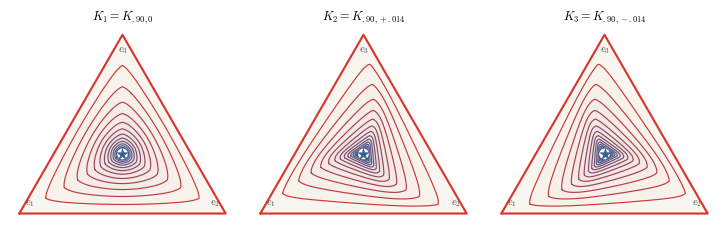

In [5]:
def draw_projective_contraction(
    ax: plt.Axes,
    problem: dict,
    panel_index: int,
) -> None:
    """Draw nonlinear nested images for one Sinkhorn kernel.

    Args:
        ax: Matplotlib axes receiving the simplex geometry.
        problem: Kernel, curves, fixed point, and contraction diagnostics.
        panel_index: One-based kernel label.

    Returns:
        None. The axes are modified in place.
    """
    ax.fill(
        SIMPLEX_VERTICES[:, 0],
        SIMPLEX_VERTICES[:, 1],
        color="#faf8f3",
        zorder=0,
    )

    for color_index, iteration in enumerate(ITERATIONS):
        curve = barycentric_to_plane(problem["curves"][iteration])
        closed_curve = np.vstack((curve, curve[0]))
        color = interp_color(color_index / (len(ITERATIONS) - 1))
        ax.fill(
            closed_curve[:, 0],
            closed_curve[:, 1],
            color=color,
            alpha=0.012,
            zorder=1 + color_index,
        )
        ax.plot(
            closed_curve[:, 0],
            closed_curve[:, 1],
            color=color,
            lw=1.50 if color_index in (0, len(ITERATIONS) - 1) else 0.84,
            alpha=0.98,
            solid_capstyle="round",
            solid_joinstyle="round",
            zorder=10 + color_index,
        )

    fixed_xy = barycentric_to_plane(problem["fixed_point"])
    ax.scatter(
        [fixed_xy[0]],
        [fixed_xy[1]],
        marker="o",
        s=58,
        color="white",
        edgecolor="none",
        zorder=29,
    )
    ax.scatter(
        [fixed_xy[0]],
        [fixed_xy[1]],
        marker="*",
        s=64,
        color=BLUE,
        edgecolor=GRAY,
        linewidth=0.38,
        zorder=30,
    )

    vertex_specs = [
        (SIMPLEX_VERTICES[0], (4, 4), "left", "bottom"),
        (SIMPLEX_VERTICES[1], (-4, 4), "right", "bottom"),
        (SIMPLEX_VERTICES[2], (0, -7), "center", "top"),
    ]
    for vertex_index, (vertex, offset, horizontal, vertical) in enumerate(
        vertex_specs,
        start=1,
    ):
        ax.annotate(
            rf"$e_{vertex_index}$",
            vertex,
            xytext=offset,
            textcoords="offset points",
            ha=horizontal,
            va=vertical,
            color=GRAY,
            fontsize=7.2,
            zorder=31,
        )

    rho_text = f"{RHO:.2f}".lstrip("0")
    if abs(problem["delta"]) < 1e-15:
        delta_text = "0"
    else:
        sign = "+" if problem["delta"] > 0.0 else "-"
        delta_text = sign + f"{abs(problem['delta']):.3f}".lstrip("0")
    ax.set_title(
        rf"$K_{panel_index}=K_{{{rho_text},{delta_text}}}$",
        fontsize=8.8,
        pad=1.8,
    )
    ax.set_aspect("equal")
    ax.set_xlim(-0.045, 1.045)
    ax.set_ylim(-0.075, 0.91)
    remove_axes(ax)


def render_figure() -> plt.Figure:
    """Render and export the projective Sinkhorn-contraction figure.

    Returns:
        Matplotlib figure containing the three kernel panels.
    """
    figure, axes = plt.subplots(1, 3, figsize=(7.25, 2.35))
    for panel_index, (ax, problem) in enumerate(
        zip(axes, PROBLEMS),
        start=1,
    ):
        draw_projective_contraction(ax, problem, panel_index)

    figure.subplots_adjust(
        left=0.010,
        right=0.990,
        bottom=0.035,
        top=0.90,
        wspace=0.055,
    )

    save_pdf(figure, OUT / "scaling-contraction.pdf", pad_inches=0.03)
    THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        THUMBNAIL,
        dpi=220,
        bbox_inches="tight",
        pad_inches=0.035,
        facecolor="white",
    )
    return figure


FIGURE = render_figure()
plt.show()

## Figure preview

The exported thumbnail below is generated from the same vector figure used by the manuscript.

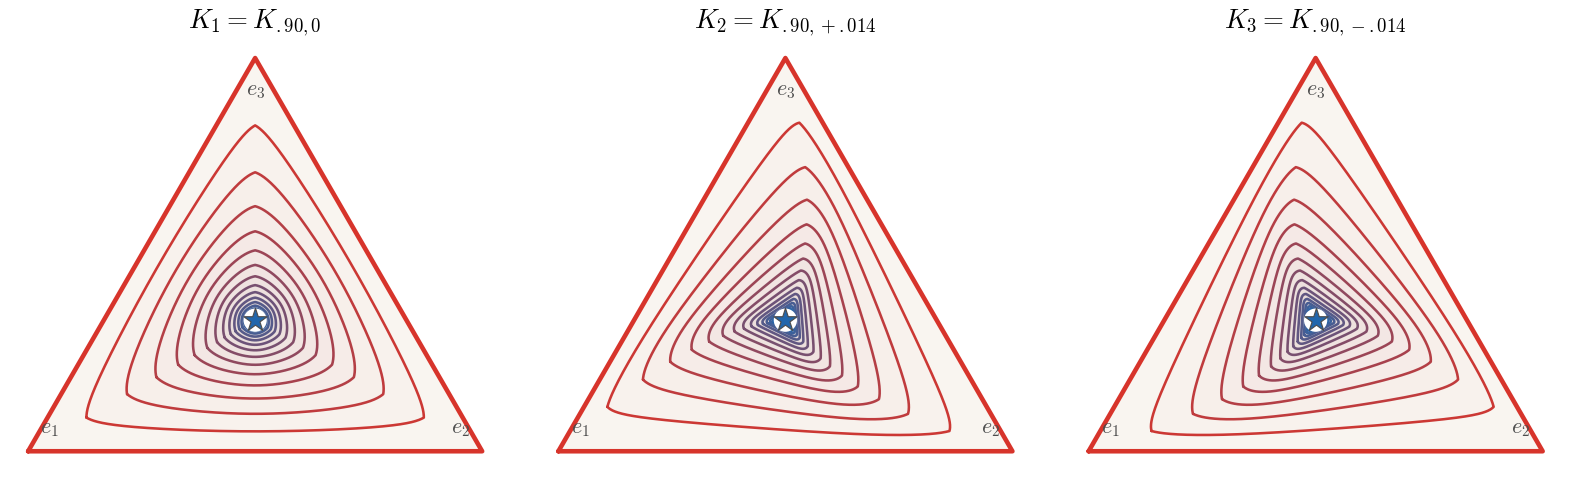

In [6]:
from IPython.display import Image, display

if Path(THUMBNAIL).exists():
    display(Image(filename=str(THUMBNAIL)))
else:
    print("Optional preview is unavailable; the numerical outputs above remain complete.")
